In [1]:
!pip install pandas
!pip install tensorflow
!pip install transformers tf-keras

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import string
import warnings
from tqdm.auto import tqdm
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Skripsi/data_prepro_labeled.csv')
df

,full_text,text_clean,text_casefolding,text_token,text_normalize,text_stopwords,text,Label_ID,Confidence_Score,Sentimen,Label_fine_tuned,Confidence_fine_tuned,sentimen_fine_tuned
0,@DS_yantie Lah itu MBG apakabar??? Pak pak,Lah itu MBG apakabar Pak pak,lah itu mbg apakabar pak pak,"['lah', 'itu', 'mbg', 'apakabar', 'pak', 'pak']","['lah', 'itu', 'mbg', 'apakabar', 'pak', 'pak']","['mbg', 'apakabar']",mbg apakabar,2,0.503783,Negatif,2,0.935089,Negatif
1,MBG anak sehat Indonesia hebat #FaktaIndonesia...,MBG anak sehat Indonesia hebat,mbg anak sehat indonesia hebat,"['mbg', 'anak', 'sehat', 'indonesia', 'hebat']","['mbg', 'anak', 'sehat', 'indonesia', 'hebat']","['mbg', 'anak', 'sehat', 'indonesia', 'hebat']",mbg anak sehat indonesia hebat,0,0.995272,Positif,0,0.947168,Positif
2,Pentingnya program MBG untuk masa depan #Fakta...,Pentingnya program MBG untuk masa depan,pentingnya program mbg untuk masa depan,"['pentingnya', 'program', 'mbg', 'untuk', 'mas...","['pentingnya ', 'program', 'mbg', 'untuk', 'm...","['pentingnya ', 'program', 'mbg']",pentingnya program mbg,1,0.665221,Netral,0,0.542193,Positif
3,MBG adalah langkah nyata membangun generasi se...,MBG adalah langkah nyata membangun generasi sehat,mbg adalah langkah nyata membangun generasi sehat,"['mbg', 'adalah', 'langkah', 'nyata', 'membang...","['mbg', 'adalah', 'langkah', 'nyata', 'membang...","['mbg', 'langkah', 'nyata', 'membangun', 'gene...",mbg langkah nyata membangun generasi sehat,0,0.528011,Positif,0,0.905261,Positif
4,@komaria_cocom MBG anakku loh kak bikin ngelus...,MBG anakku loh kak bikin ngelus dada Buat hari...,mbg anakku loh kak bikin ngelus dada buat hari...,"['mbg', 'anakku', 'loh', 'kak', 'bikin', 'ngel...","['mbg', 'anakku', 'kok', 'kak', 'buat', 'ngelu...","['mbg', 'anakku', 'kak', 'ngelus', 'dada', 'sa...",mbg anakku kak ngelus dada salak susu uht kota...,1,0.990892,Netral,1,0.526549,Netral
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7357,Naahh!! Dengan adanya program MBG anak-anak ga...,Naahh Dengan adanya program MBG anakanak gaj p...,naahh dengan adanya program mbg anakanak gaj p...,"['naahh', 'dengan', 'adanya', 'program', 'mbg'...","['naahh', 'dengan', 'adanya', 'program', 'mbg'...","['naahh', 'program', 'mbg', 'anakanak', 'gaj',...",naahh program mbg anakanak gaj membeli makanan...,0,0.979206,Positif,0,0.767132,Positif
7358,@ranie__14 @endahm7 @Dandhy_Laksono yang dimak...,yang dimaksudkan itu program MBG di daerah yan...,yang dimaksudkan itu program mbg di daerah yan...,"['yang', 'dimaksudkan', 'itu', 'program', 'mbg...","['yang', 'dimaksudkan', 'itu', 'program', 'mbg...","['program', 'mbg', 'daerah', 'terpapar', 'penc...",program mbg daerah terpapar pencemaran logam b...,2,0.661973,Negatif,2,0.924340,Negatif
7359,Pertemuan Prabowo-Macron Bahas Isu MBG hingga ...,Pertemuan PrabowoMacron Bahas Isu MBG hingga A...,pertemuan prabowomacron bahas isu mbg hingga a...,"['pertemuan', 'prabowomacron', 'bahas', 'isu',...","['pertemuan', 'prabowomacron', 'bahas', 'isu',...","['pertemuan', 'prabowomacron', 'bahas', 'isu',...",pertemuan prabowomacron bahas isu mbg alutsista,1,0.996780,Netral,1,0.979394,Netral
7360,@txtdrimedia Yg dikasih MBG jutaan siswa kalan...,Yg dikasih MBG jutaan siswa kalangan SDSMA Buk...,yg dikasih mbg jutaan siswa kalangan sdsma buk...,"['yg', 'dikasih', 'mbg', 'jutaan', 'siswa', 'k...","['yang', 'dikasih', 'mbg', 'jutaan', 'siswa', ...","['dikasih', 'mbg', 'jutaan', 'siswa', 'kalanga...",dikasih mbg jutaan siswa kalangan sdsma bukti ...,2,0.965784,Negatif,2,0.651894,Negatif


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7362 entries, 0 to 7361
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   full_text              7362 non-null   object 
 1   text_clean             7362 non-null   object 
 2   text_casefolding       7362 non-null   object 
 3   text_token             7362 non-null   object 
 4   text_normalize         7362 non-null   object 
 5   text_stopwords         7362 non-null   object 
 6   text                   7362 non-null   object 
 7   Label_ID               7362 non-null   int64  
 8   Confidence_Score       7362 non-null   float64
 9   Sentimen               7362 non-null   object 
 10  Label_fine_tuned       7362 non-null   int64  
 11  Confidence_fine_tuned  7362 non-null   float64
 12  sentimen_fine_tuned    7362 non-null   object 
dtypes: float64(2), int64(2), object(9)
memory usage: 747.8+ KB


In [5]:
# Menampilkan jumlah masing-masing sentimen
sentimen_count = df['sentimen_fine_tuned'].value_counts()
print(sentimen_count)

sentimen_fine_tuned
Negatif    4004
Netral     1866
Positif    1492
Name: count, dtype: int64


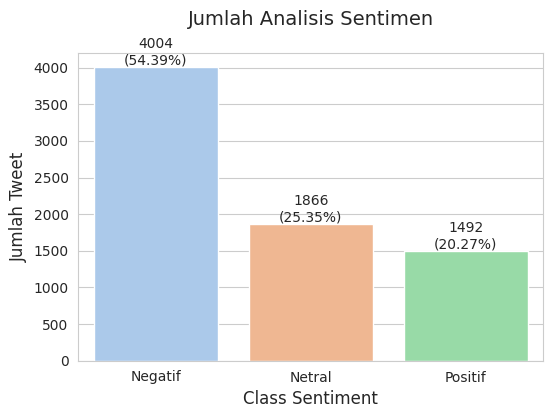

In [6]:
sentimen_count = df['sentimen_fine_tuned'].value_counts()
sns.set_style('whitegrid')
fig,ax=plt.subplots(figsize=(6,4))
ax = sns.barplot(x=sentimen_count.index, y=sentimen_count.values, palette='pastel')
plt.title('Jumlah Analisis Sentimen', fontsize=14, pad=20)
plt.xlabel('Class Sentiment', fontsize=12)
plt.ylabel('Jumlah Tweet', fontsize=12)
total = len(df['sentimen_fine_tuned'])

for i, count in enumerate(sentimen_count.values):
  percentage = f'{100*count/total:.2f}%'
  ax.text(i, count + 0.10, f'{count}\n({percentage})' , ha='center', va='bottom')

plt.show()

# Splitting Data

In [9]:
from sklearn.model_selection import train_test_split
import ast

# Define features (X) and target (Y)
X = df['text'].astype(str).values
Y = df['Label_fine_tuned'].values

# Split the data into training and testing sets (80% train, 20% test)

X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
    X, Y, df.index, test_size=0.2, random_state=42, stratify=Y # Stratify to maintain class distribution
)

print(f"Ukuran data training: {len(X_train)} baris")
print(f"Ukuran data testing: {len(X_test)} baris")

Ukuran data training: 5889 baris
Ukuran data testing: 1473 baris


# Long-Short Term Memory

In [10]:
import numpy as np
import tensorflow as tf
from transformers import AutoModel, AutoTokenizer
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Embedding, Bidirectional, LSTM, Dense,
                                     Dropout, GlobalMaxPooling1D, GlobalAveragePooling1D,
                                     BatchNormalization, SpatialDropout1D, Input, concatenate)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --- 1. LOAD INDOBERT ---
model_name = "indolem/indobert-base-uncased"
print("Sedang mengambil model IndoBERT...")

tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)

bert_embeddings_matrix = bert_model.embeddings.word_embeddings.weight.detach().numpy()
vocab_size = bert_embeddings_matrix.shape[0]
embedding_dim = bert_embeddings_matrix.shape[1]

print(f"✅ Kamus Siap! Vocab: {vocab_size}, Dimensi: {embedding_dim}")

# --- 2. PREPROCESSING (Fix NaN & Clean) ---
def prepare_data_bert(texts, max_len=35):
    # Memaksa konversi string dan menangani NaN secara eksplisit
    texts_clean = [str(t) if t is not None else "kosong" for t in texts]

    tokens = tokenizer(
        texts_clean,
        max_length=max_len,
        truncation=True,
        padding='max_length',
        return_tensors='np'
    )
    return tokens['input_ids']

print("Mengonversi teks ke token angka...")
X_train_final = prepare_data_bert(X_train)
X_test_final = prepare_data_bert(X_test)

# --- 3. ARSITEKTUR ADJUSTED (HYBRID POOLING) ---

input_layer = Input(shape=(35,))

x = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[bert_embeddings_matrix],
    trainable=False,
    name="IndoBERT_Embedding"
)(input_layer)

x = SpatialDropout1D(0.4)(x)

# LSTM dengan Recurrent Dropout
lstm_out = Bidirectional(LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2))(x)
max_pool = GlobalMaxPooling1D()(lstm_out)
avg_pool = GlobalAveragePooling1D()(lstm_out)
combined = concatenate([max_pool, avg_pool])

# CLASSIFIER LAYER
x = Dense(256, activation='relu')(combined)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)

output_layer = Dense(3, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output_layer)

# --- 4. OPTIMIZER & COMPILING ---

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, verbose=1)
]

# --- 5. TRAINING ---
print("\n--- Memulai Training dengan Hybrid Architecture ---")
history = model.fit(
    X_train_final, y_train,
    validation_data=(X_test_final, y_test),
    epochs=30,
    batch_size=64,
    callbacks=callbacks
)

# --- 6. EVALUASI ---
results = model.evaluate(X_test_final, y_test)
print(f"\n✅ Akurasi Akhir pada Data Testing: {results[1]*100:.2f}%")

Sedang mengambil model IndoBERT...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

...

✅ Kamus Siap! Vocab: 31923, Dimensi: 768
Mengonversi teks ke token angka...


Error during conversion: AttributeError("'str' object has no attribute 'decode'")



--- Memulai Training dengan Hybrid Architecture ---
Epoch 1/30


model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

93/93 ━━━━━━━━━━━━━━━━━━━━ 35s 230ms/step - accuracy: 0.4522 - loss: 1.1917 - val_accuracy: 0.5438 - val_loss: 1.0069 - learning_rate: 0.0010
Epoch 2/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 20s 214ms/step - accuracy: 0.5400 - loss: 0.9735 - val_accuracy: 0.5852 - val_loss: 0.9393 - learning_rate: 0.0010
Epoch 3/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 22s 242ms/step - accuracy: 0.6113 - loss: 0.8593 - val_accuracy: 0.6511 - val_loss: 0.8172 - learning_rate: 0.0010
Epoch 4/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 43s 264ms/step - accuracy: 0.6662 - loss: 0.7539 - val_accuracy: 0.6633 - val_loss: 0.7322 - learning_rate: 0.0010
Epoch 5/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 19s 207ms/step - accuracy: 0.7041 - loss: 0.6763 - val_accuracy: 0.7719 - val_loss: 0.5657 - learning_rate: 0.0010
Epoch 6/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 20s 219ms/step - accuracy: 0.7203 - loss: 0.6548 - val_accuracy: 0.7794 - val_loss: 0.5719 - learning_rate: 0.0010
Epoch 7/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 24s 255ms/step - accuracy: 0.7666 - loss: 0.5492 - val_

In [11]:
model.get_layer("IndoBERT_Embedding").trainable = True
optimizer_fine = tf.keras.optimizers.Adam(learning_rate=2e-5)

model.compile(
    optimizer=optimizer_fine,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    X_train_final, y_train,
    validation_data=(X_test_final, y_test),
    epochs=7,
    batch_size=32,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
    ]
)

# 4. Cek hasil akhir
final_results = model.evaluate(X_test_final, y_test)
print(f"\n🚀 HASIL AKHIR: {final_results[1]*100:.2f}%")

Epoch 1/7
185/185 ━━━━━━━━━━━━━━━━━━━━ 54s 253ms/step - accuracy: 0.9036 - loss: 0.2468 - val_accuracy: 0.8405 - val_loss: 0.4437
Epoch 2/7
185/185 ━━━━━━━━━━━━━━━━━━━━ 81s 250ms/step - accuracy: 0.8965 - loss: 0.2646 - val_accuracy: 0.8405 - val_loss: 0.4443
Epoch 3/7
185/185 ━━━━━━━━━━━━━━━━━━━━ 47s 253ms/step - accuracy: 0.8965 - loss: 0.2540 - val_accuracy: 0.8418 - val_loss: 0.4425
Epoch 4/7
185/185 ━━━━━━━━━━━━━━━━━━━━ 49s 263ms/step - accuracy: 0.9039 - loss: 0.2481 - val_accuracy: 0.8398 - val_loss: 0.4442
Epoch 5/7
185/185 ━━━━━━━━━━━━━━━━━━━━ 80s 254ms/step - accuracy: 0.9111 - loss: 0.2222 - val_accuracy: 0.8445 - val_loss: 0.4450
Epoch 6/7
185/185 ━━━━━━━━━━━━━━━━━━━━ 47s 252ms/step - accuracy: 0.9108 - loss: 0.2218 - val_accuracy: 0.8445 - val_loss: 0.4408
Epoch 7/7
185/185 ━━━━━━━━━━━━━━━━━━━━ 47s 253ms/step - accuracy: 0.9209 - loss: 0.2034 - val_accuracy: 0.8425 - val_loss: 0.4433
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.8363 - loss: 0.4521

🚀 HASIL AKHIR: 

47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step

PREDICTION & CLASSIFICATION REPORT (FIXED LABELS)

✅ LSTM Accuracy: 0.8445 (84.45%)

               precision    recall  f1-score   support

     Positif       0.76      0.83      0.79       299
      Netral       0.77      0.81      0.79       373
     Negatif       0.92      0.87      0.89       801

    accuracy                           0.84      1473
   macro avg       0.82      0.84      0.83      1473
weighted avg       0.85      0.84      0.85      1473



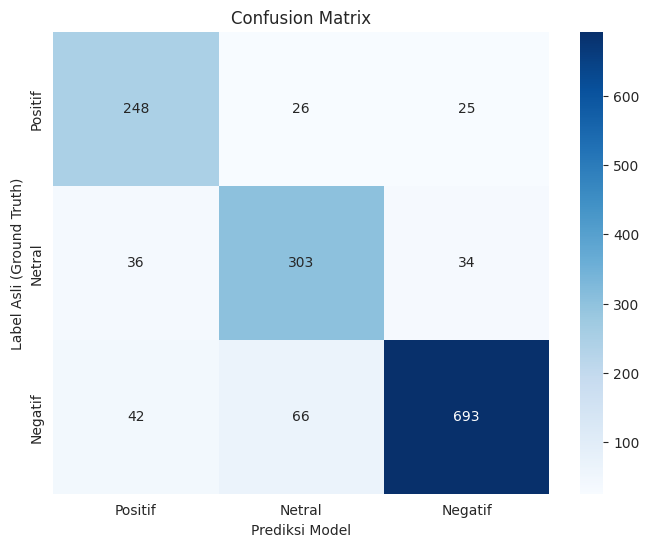

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ambil prediksi dan hitung akurasi
y_pred_probs = model.predict(X_test_final)
y_pred = np.argmax(y_pred_probs, axis=1)
loss, test_accuracy = model.evaluate(X_test_final, y_test, verbose=0)

# 2. Cetak Output dengan Urutan Label yang Benar (0:Pos, 1:Neu, 2:Neg)
print("\n" + "="*70)
print("PREDICTION & CLASSIFICATION REPORT (FIXED LABELS)")
print("="*70)
print(f"\n✅ LSTM Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("\n", classification_report(y_test, y_pred, target_names=['Positif', 'Netral', 'Negatif']))
print("="*70)

# 3. Visualisasi Confusion Matrix dengan Label Baru
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Positif', 'Netral', 'Negatif'],
            yticklabels=['Positif', 'Netral', 'Negatif'])
plt.xlabel('Prediksi Model')
plt.ylabel('Label Asli (Ground Truth)')
plt.title('Confusion Matrix')
plt.show()

In [20]:
import pandas as pd

# Assuming y_test and y_pred are already available from model evaluation
# Assuming X_test is also available from the initial data splitting
# Assuming df is the original DataFrame and indices_test contains the original indices of the test set

# Define the mapping from numerical labels to sentiment names
# Based on your specified mapping: 0: Negatif, 1: Netral, 2: Positif
numerical_to_label = {0: 'Positif', 1: 'Netral', 2: 'Negatif'}

# Convert numerical labels back to original sentiment names
actual_sentiment = [numerical_to_label[label] for label in y_test]
predicted_sentiment = [numerical_to_label[label] for label in y_pred]

# Get the original text using the test set indices
original_text = df.loc[indices_test, 'text'].tolist()


# Create a DataFrame
results_df_sentiment_names = pd.DataFrame({
    'Original_Text': original_text,
    'Actual_Label': actual_sentiment,
    'Predicted_Label': predicted_sentiment
})

# Display the first few rows of the DataFrame
print("DataFrame with Actual vs Predicted Sentiment Names and Original Text:")
display(results_df_sentiment_names.head())

# Optional: Display rows where actual and predicted labels differ
print("\nExamples where Actual and Predicted Labels Differ:")
display(results_df_sentiment_names[results_df_sentiment_names['Actual_Label'] != results_df_sentiment_names['Predicted_Label']].head())


# Define the path to save the CSV file
# Make sure the directory exists and you have write permissions
csv_save_path_sentiment_names = '/content/drive/MyDrive/Skripsi/Hasil_Predictions_LSTM.csv' # Changed filename

# Save the DataFrame to a CSV file
results_df_sentiment_names.to_csv(csv_save_path_sentiment_names, index=False)

print(f"\nDataFrame saved to: {csv_save_path_sentiment_names}")

DataFrame with Actual vs Predicted Sentiment Names and Original Text:


,Original_Text,Actual_Label,Predicted_Label
0,dukung program makan bergizi gratis anakanak P...,Positif,Positif
1,pertumbuhan didukung asupan gizi baiklanjutkan...,Netral,Positif
2,update mbg teman-teman siswa berangkat deh,Netral,Positif
3,mbg iya bahasa beliau klpk umur,Netral,Negatif
4,nomer call center email dm laporan pengaduan p...,Positif,Positif



Examples where Actual and Predicted Labels Differ:


,Original_Text,Actual_Label,Predicted_Label
1,pertumbuhan didukung asupan gizi baiklanjutkan...,Netral,Positif
2,update mbg teman-teman siswa berangkat deh,Netral,Positif
3,mbg iya bahasa beliau klpk umur,Netral,Negatif
5,yaampun kedelai impor gandum tertawa prabowo p...,Netral,Positif
8,mbg ntb libur sekolah menyediakan makanan berg...,Positif,Netral



DataFrame saved to: /content/drive/MyDrive/Skripsi/Hasil_Predictions_LSTM.csv


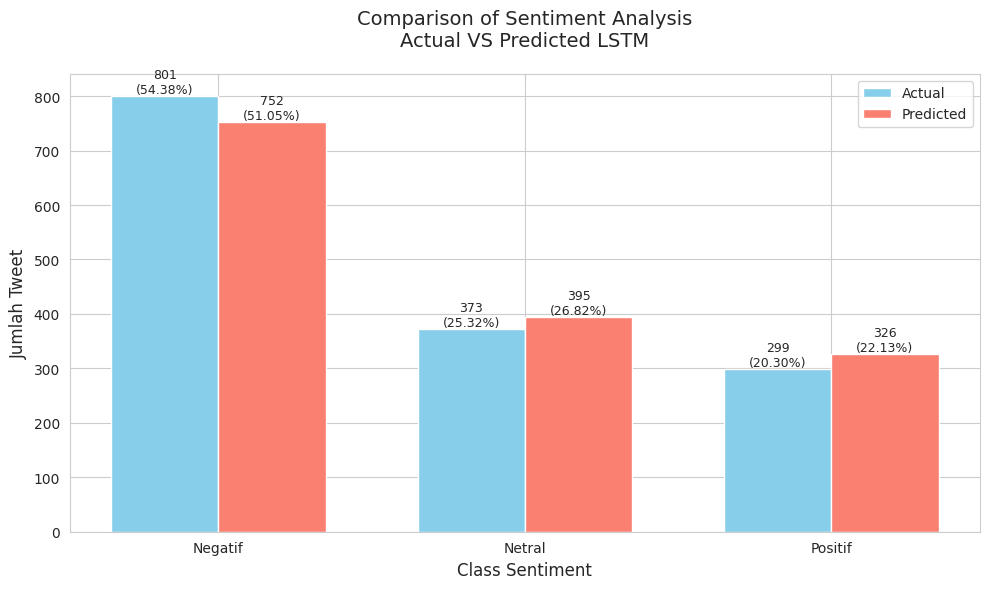

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Use the results_df_sentiment_names DataFrame created earlier
# Compare Actual vs Predicted counts using results_df_sentiment_names
# We need to get counts for each sentiment name
actual_sentiment_counts = results_df_sentiment_names['Actual_Label'].value_counts()
predicted_sentiment_counts = results_df_sentiment_names['Predicted_Label'].value_counts()

# Define the desired order of labels for the plot
sentiment_labels_ordered = ['Negatif', 'Netral', 'Positif']

# Reindex the counts to ensure consistent order for plotting
actual_sentiment_counts = actual_sentiment_counts.reindex(sentiment_labels_ordered, fill_value=0)
predicted_sentiment_counts = predicted_sentiment_counts.reindex(sentiment_labels_ordered, fill_value=0)


comparison_df_sentiment = pd.DataFrame({
    'Actual': actual_sentiment_counts,
    'Predicted': predicted_sentiment_counts
})

# Create Plot
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.35
index = range(len(comparison_df_sentiment))

# Plot Actual
ax.bar([i - bar_width / 2 for i in index], comparison_df_sentiment['Actual'], width=bar_width, label='Actual', color='skyblue')

# Plot Predicted
ax.bar([i + bar_width / 2 for i in index], comparison_df_sentiment['Predicted'], width=bar_width, label='Predicted', color='salmon')

# Set labels and title
ax.set_xlabel('Class Sentiment', fontsize=12)
ax.set_ylabel('Jumlah Tweet', fontsize=12)
ax.set_title('Comparison of Sentiment Analysis\nActual VS Predicted LSTM', fontsize=14, pad=20) # Update title
ax.set_xticks(index)
# Use sentiment names for ticks based on the ordered list
ax.set_xticklabels(sentiment_labels_ordered)
ax.legend()

# Add counts and percentages above bars
for i in index:
    actual_count = comparison_df_sentiment['Actual'].iloc[i]
    predicted_count = comparison_df_sentiment['Predicted'].iloc[i]

    actual_percentage = f'({(actual_count / comparison_df_sentiment["Actual"].sum()) * 100:.2f}%)' if comparison_df_sentiment["Actual"].sum() > 0 else '(0.00%)'
    predicted_percentage = f'({(predicted_count / comparison_df_sentiment["Predicted"].sum()) * 100:.2f}%)' if comparison_df_sentiment["Predicted"].sum() > 0 else '(0.00%)'

    ax.text(i - bar_width / 2, actual_count + 0.01, f'{int(actual_count)}\n{actual_percentage}', ha='center', va='bottom', fontsize=9)
    ax.text(i + bar_width / 2, predicted_count + 0.01, f'{int(predicted_count)}\n{predicted_percentage}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [22]:
import pandas as pd

# Get value counts for actual labels
actual_counts = pd.Series(y_test).value_counts().sort_index()
print("Original (Actual) Class Distribution:")
print(actual_counts)

# Get value counts for predicted labels
predicted_counts = pd.Series(y_pred).value_counts().sort_index()
print("\nPredicted Class Distribution:")
print(predicted_counts)

# You can also combine them into a DataFrame for easier comparison
comparison_counts_df = pd.DataFrame({
    'Actual': actual_counts,
    'Predicted': predicted_counts
}).fillna(0).astype(int)

print("\nComparison of Actual vs Predicted Counts:")
display(comparison_counts_df)

Original (Actual) Class Distribution:
0    299
1    373
2    801
Name: count, dtype: int64

Predicted Class Distribution:
0    326
1    395
2    752
Name: count, dtype: int64

Comparison of Actual vs Predicted Counts:


,Actual,Predicted
0,299,326
1,373,395
2,801,752
